# Retail Demand Forecating using Random Forest

### Problem Statement

Retail companies must predict future product demand to manage inventory efficiently

Goal : 

* Forecast product sales

* Reduce stockouts

* Optimize inventory planning

### 1. Data Loading

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("train.csv")
stores = pd.read_csv("stores.csv")
transactions = pd.read_csv("transactions.csv")
holidays = pd.read_csv("holidays_events.csv")


In [3]:
train["date"] = pd.to_datetime(train["date"])
transactions["date"] = pd.to_datetime(transactions["date"])
holidays["date"] = pd.to_datetime(holidays["date"])

df = train.merge(stores, on = 'store_nbr', how = "left")
df = df.merge(transactions, on = ["date", "store_nbr"], how = "left")
df = df.merge(holidays, on = "date", how = "left")

In [4]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,Primer dia del ano,False


In [5]:
df.tail()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,type_y,locale,locale_name,description,transferred
3054343,3000883,2017-08-15,9,POULTRY,438.133,0,Quito,Pichincha,B,6,2155.0,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3054344,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,6,2155.0,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3054345,3000885,2017-08-15,9,PRODUCE,2419.729,148,Quito,Pichincha,B,6,2155.0,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3054346,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,6,2155.0,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3054347,3000887,2017-08-15,9,SEAFOOD,16.000,0,Quito,Pichincha,B,6,2155.0,Holiday,Local,Riobamba,Fundacion de Riobamba,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 16 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type_x        object        
 9   cluster       int64         
 10  transactions  float64       
 11  type_y        object        
 12  locale        object        
 13  locale_name   object        
 14  description   object        
 15  transferred   object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(9)
memory usage: 372.8+ MB


In [7]:
df.describe()

,id,date,store_nbr,sales,onpromotion,cluster,transactions
count,3.054348e+06,3054348,3.054348e+06,3.054348e+06,3.054348e+06,3.054348e+06,2.805231e+06
mean,1.504277e+06,2015-04-26 12:11:45.717619200,2.750000e+01,3.590209e+02,2.617480e+00,8.481481e+00,1.697071e+03
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,5.000000e+00
25%,7.546768e+05,2014-03-01 00:00:00,1.400000e+01,0.000000e+00,0.000000e+00,4.000000e+00,1.046000e+03
50%,1.507572e+06,2015-04-28 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00,8.500000e+00,1.395000e+03
75%,2.255120e+06,2016-06-22 00:00:00,4.100000e+01,1.960110e+02,0.000000e+00,1.300000e+01,2.081000e+03
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02,1.700000e+01,8.359000e+03
std,8.662610e+05,NaN,1.558579e+01,1.107286e+03,1.225494e+01,4.649735e+00,9.668317e+02


In [8]:
df.isnull().sum()

id                    0
date                  0
store_nbr             0
family                0
sales                 0
onpromotion           0
city                  0
state                 0
type_x                0
cluster               0
transactions     249117
type_y          2551824
locale          2551824
locale_name     2551824
description     2551824
transferred     2551824
dtype: int64

### 2. Data Cleaning

In [9]:
df.fillna(0, inplace = True)
df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,Ecuador,Primer dia del ano,False


In [10]:
df.isnull().sum()

id              0
date            0
store_nbr       0
family          0
sales           0
onpromotion     0
city            0
state           0
type_x          0
cluster         0
transactions    0
type_y          0
locale          0
locale_name     0
description     0
transferred     0
dtype: int64

In [11]:
df = df.drop(["description", "locale_name"], axis = 1)
df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,type_y,locale,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,False


### 3. Feature Engineering

In [12]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,type_y,locale,transferred,year,month,day_of_week
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,False,2013,1,1
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,False,2013,1,1
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,False,2013,1,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,False,2013,1,1
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,0.0,Holiday,National,False,2013,1,1


### 4. Exploratory Data Analysis

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

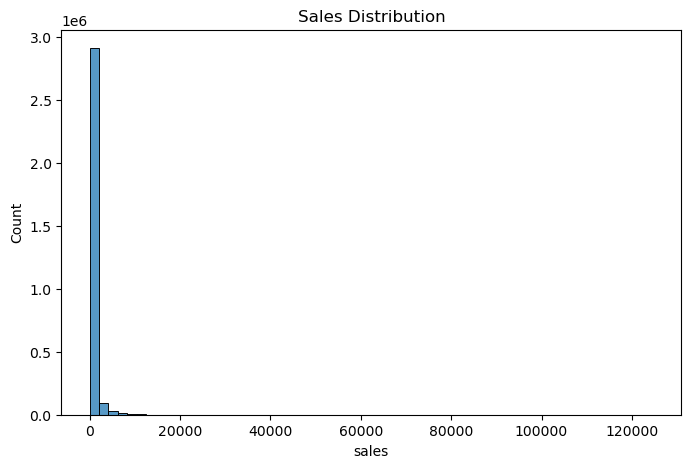

In [14]:
# Sales Distribution

plt.figure(figsize = (8, 5))
sns.histplot(df["sales"], bins = 60)
plt.title("Sales Distribution")
plt.show()

### Insight

* Most sales values are small

* Few products have very high demand

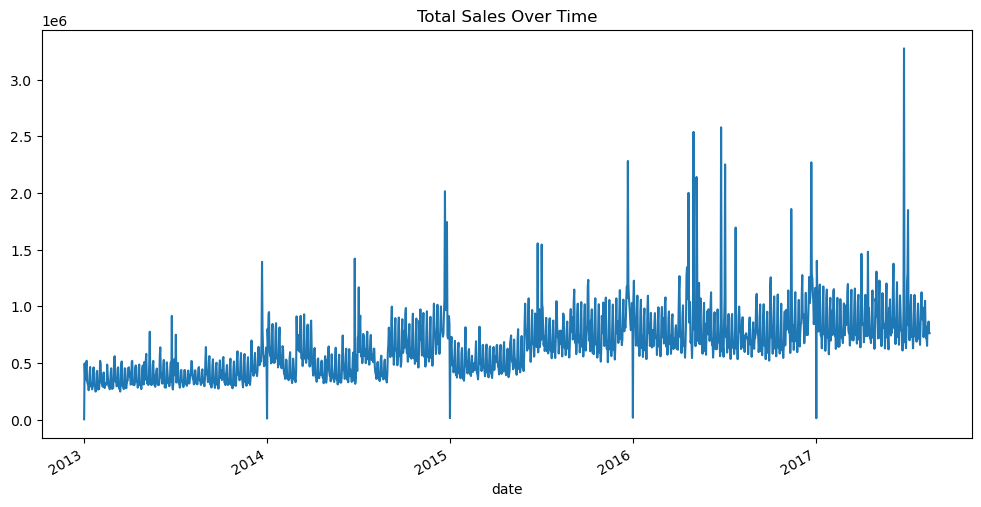

In [15]:
# Total Sales over Time

sales_trend = df.groupby("date")["sales"].sum()

plt.figure(figsize = (12, 6))
sales_trend.plot()
plt.title("Total Sales Over Time")
plt.show()

### Insight

* Sales fluctuate over time

* Seasonal trends may exist

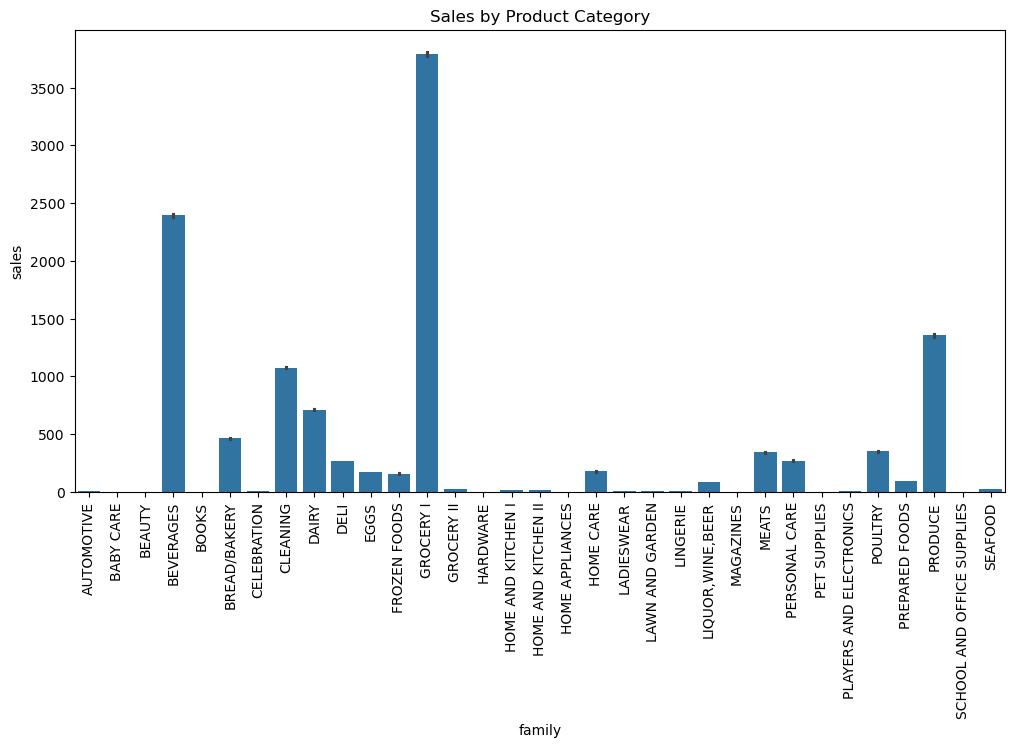

In [16]:
# Sales by product category

plt.figure(figsize = (12, 6))
sns.barplot(x = "family", y = "sales", data = df)
plt.xticks(rotation = 90)
plt.title("Sales by Product Category")
plt.show()

### Insight 

* Some product families dominate sales

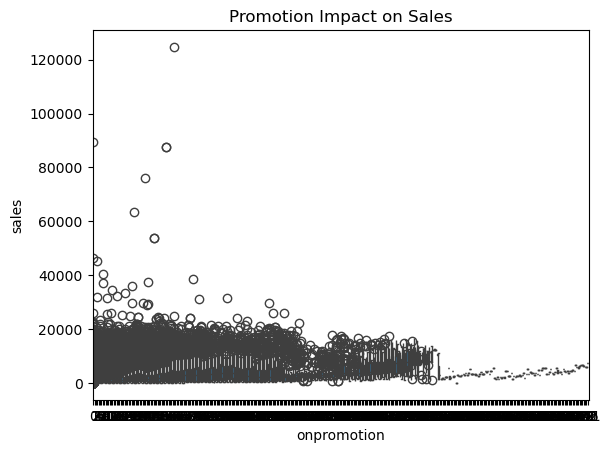

In [17]:
# Promotion impact on sales

sns.boxplot(x = "onpromotion", y = "sales", data = df)
plt.title("Promotion Impact on Sales")
plt.show()

### Insight

Promotions significantly increases demand

<function matplotlib.pyplot.show(close=None, block=None)>

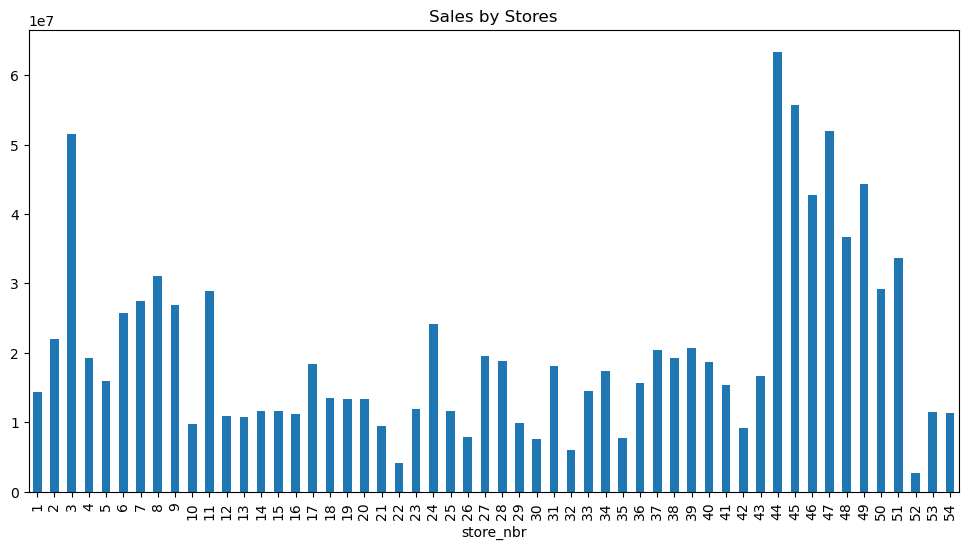

In [18]:
# Sales by Stores

store_sales = df.groupby("store_nbr")["sales"].sum()
store_sales.plot(kind = "bar", figsize = (12, 6))
plt.title("Sales by Stores")
plt.show

### Insight

* Some stores perform better than others

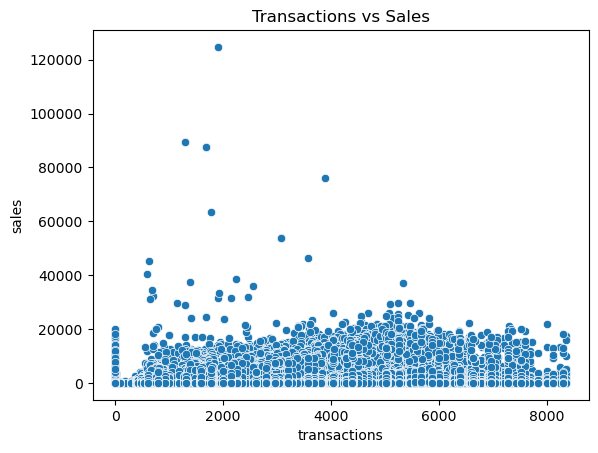

In [19]:
# Transactions vs Sales

sns.scatterplot(x = "transactions", y = "sales", data = df)
plt.title("Transactions vs Sales")
plt.show()

### Insight

* Higher customer transactions lead to higher sales

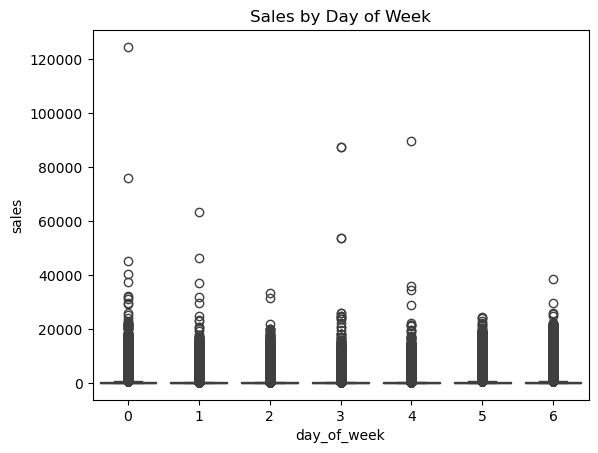

In [20]:
# Sales by day of week

sns.boxplot(x = "day_of_week", y = "sales", data = df)
plt.title("Sales by Day of Week")
plt.show()

### Insight

* Certain days may have higher demand

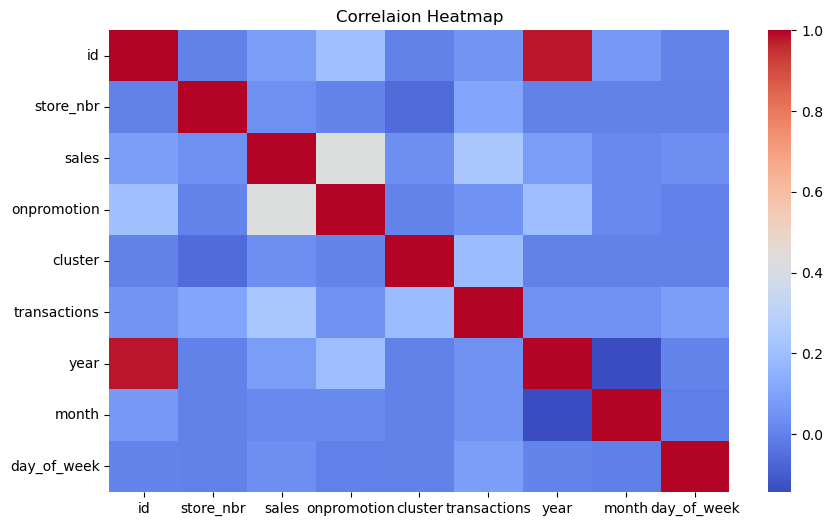

In [21]:
# Correlation heatmap

corr = df.corr(numeric_only = True)

plt.figure(figsize = (10, 6))
sns.heatmap(corr, cmap = "coolwarm")
plt.title("Correlaion Heatmap")
plt.show()

### Insight

* Promotions and transactions show positive correlation with sales

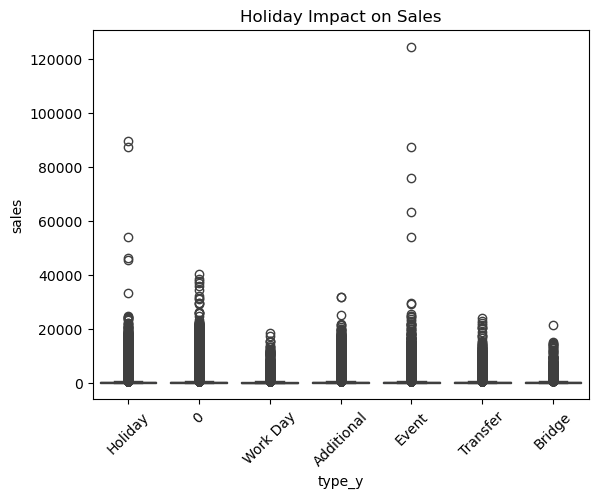

In [22]:
# Holiday impact

sns.boxplot(x = "type_y", y = "sales", data = df)
plt.xticks(rotation = 45)
plt.title("Holiday Impact on Sales")
plt.show()

### Insight

* Holidays affect sales patterns

### 5. Encoding Categorical Features

In [23]:
df = pd.get_dummies(df, drop_first = True)
df.head()

,id,date,store_nbr,sales,onpromotion,cluster,transactions,year,month,day_of_week,...,type_y_Additional,type_y_Bridge,type_y_Event,type_y_Holiday,type_y_Transfer,type_y_Work Day,locale_Local,locale_National,locale_Regional,transferred_True
0,0,2013-01-01,1,0.0,0,13,0.0,2013,1,1,...,False,False,False,True,False,False,False,True,False,False
1,1,2013-01-01,1,0.0,0,13,0.0,2013,1,1,...,False,False,False,True,False,False,False,True,False,False
2,2,2013-01-01,1,0.0,0,13,0.0,2013,1,1,...,False,False,False,True,False,False,False,True,False,False
3,3,2013-01-01,1,0.0,0,13,0.0,2013,1,1,...,False,False,False,True,False,False,False,True,False,False
4,4,2013-01-01,1,0.0,0,13,0.0,2013,1,1,...,False,False,False,True,False,False,False,True,False,False


In [35]:
df = df.drop("id", axis = 1)

In [36]:
df.head()

,date,store_nbr,sales,onpromotion,cluster,transactions,year,month,day_of_week,family_BABY CARE,...,type_y_Additional,type_y_Bridge,type_y_Event,type_y_Holiday,type_y_Transfer,type_y_Work Day,locale_Local,locale_National,locale_Regional,transferred_True
0,2013-01-01,1,0.0,0,13,0.0,2013,1,1,False,...,False,False,False,True,False,False,False,True,False,False
1,2013-01-01,1,0.0,0,13,0.0,2013,1,1,True,...,False,False,False,True,False,False,False,True,False,False
2,2013-01-01,1,0.0,0,13,0.0,2013,1,1,False,...,False,False,False,True,False,False,False,True,False,False
3,2013-01-01,1,0.0,0,13,0.0,2013,1,1,False,...,False,False,False,True,False,False,False,True,False,False
4,2013-01-01,1,0.0,0,13,0.0,2013,1,1,False,...,False,False,False,True,False,False,False,True,False,False


### 6. Define Features and Target

In [37]:
df_sample = df.sample(n = 100000, random_state = 42)

In [38]:
X = df_sample.drop(["sales", "date"], axis = 1)
y = df_sample["sales"]

### 7. Train Test Split

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

### 8. Train Model 

In [40]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators = 20,
    max_depth = 8,
    random_state = 42,
)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, n_estimators=20, random_state=42)

In [41]:
y_pred = model.predict(X_test)
y_pred

array([  43.28795845,  180.69974567, 2452.7507168 , ...,  531.88389403,
         43.28795845,   43.28795845])

In [42]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE :", rmse)
print("R2 Score :", r2)

RMSE : 361.97234350173227
R2 Score : 0.8969213413828913


### 9. Feature Importance

In [43]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : importance
}).sort_values("Importance", ascending = False)

print(feature_importance.head(10))

             Feature  Importance
18  family_GROCERY I    0.340257
3       transactions    0.317418
9   family_BEVERAGES    0.134460
1        onpromotion    0.062509
36    family_PRODUCE    0.040986
13   family_CLEANING    0.024521
4               year    0.023367
14      family_DAIRY    0.010415
6        day_of_week    0.009910
5              month    0.007398


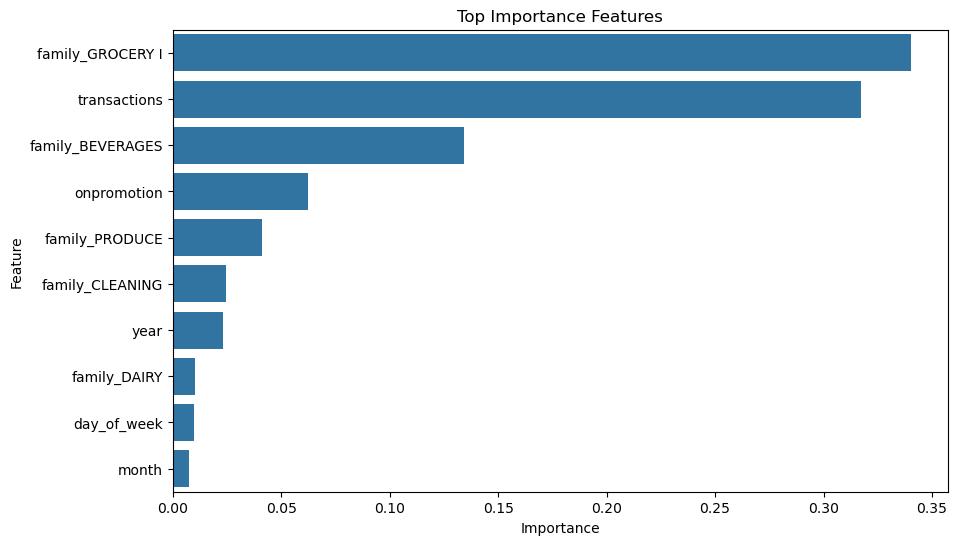

In [45]:
plt.figure(figsize = (10, 6))

sns.barplot(
    x = "Importance",
    y = "Feature",
    data = feature_importance.head(10)
)
plt.title("Top Importance Features")
plt.show()

### 10. Save the Model

In [47]:
import joblib

joblib.dump(model, "sales_prediction_model.pkl")

['sales_prediction_model.pkl']